# Cortical state prediction based on mouse respiration data
Author: Nicolas Chenouard
Date: 10/31/2024

Script associated to the manuscript: Respiratory pauses highlight sleep architecture  in mice 
by : Giulio Casali, Camille Miermon, Geoffrey Terral, Pascal Ravassard, Tiphaine Dolique, Evan Harrell, Edith Lesburguères, David Jarriault, Frédéric Gambino, Nicolas Chenouard, Lisa Roux

Paths to different files are required:

In [14]:
# a data file generated by BreathMetrics+
data_file = 'Data.mat'

# respiration normalization parameters
normalization_parameters_file = 'default_normalization_parameters.npy'


# pretrained model weights
weightFile = 'Model-validation3C060.h5'

In [15]:
import numpy as np
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import backend as K

from matplotlib import cm
import matplotlib.pyplot as plt

import scipy.io

import h5py

In [26]:
def normalize_data(data_features, normalization_parameters):
    """
    Normalize the 20 respiration features for use with a CNN
    :param data_features: respiration parameters to normalize
    :param normalization_parameters: normalization factors
    :return:normalized parameters 
    """
    for i in range(data_features.shape[1]):
        data_features[:, i] = (data_features[:, i] -  normalization_parameters[i, 0])/normalization_parameters[i, 1]
    data_features[np.isnan(data_features)] = 0
    data_features[np.isinf(data_features)] = 0        
    
    return data_features

def moving_sum(x, kernel_size):
    """
    Moving sum along a 1D vector
    :param kernel_size: the size of the sum
    """
    return np.convolve(x, np.ones(kernel_size), 'same')

def compute_features(data_features, std_width=10):
    """
    Apply log-normalization to respiration features and compute local standard deviations
    :param data_features: respiration data to procss
    :param std_width: the size of the local window for local standard deviation computation
    :return: 20 features characterizing respiration
    """
    y = np.zeros((data_features.shape[0], 20))
    epsilon = 1e-4
    y[:, 0:10] =  np.log(epsilon + np.abs(data_features[:, 0:10]))    
    counts = moving_sum(np.ones((y.shape[0])), std_width)
    
    for i in range(10):
        c = np.divide(moving_sum(y[:, i], std_width), counts) # moving average
        c2 = np.divide(moving_sum(np.square(y[:, i]), std_width), counts) # moving average    
        y[:, 10+i] = np.sqrt(c2 - np.square(c))
    return y

def load_session(filename, use_manual_states=True):
    """
    Load respiration information from a file generated by BreathMetrics+
    :return: data_features as the respiration information, data_states as the cortical state
    """
    with h5py.File(filename, 'r') as f:
        data_features = np.asarray(f['Data/Single/Matrix']).astype('float32')
        if use_manual_states:
            data_states = np.asarray(f['Data/Single/State'])
        else:
            data_states = np.asarray(f['Data/Single/PopAutomatedState'])
        sampling_rate=np.asarray(f['Data/Single/Fs'])[0][0].astype('int') 
        np.nan_to_num(data_states, copy = False)
        return data_features.T, data_states.T, sampling_rate   

def group_cycles_repeat(d,
                        g,
                        stride=1):
    """
    Extract local neighbors in a temporal series of features
    :param: d: the data to process
    :param: g: the grouping size
    :param: stride: stride factor for the extraction
    :return: grouped data and indices of the extracted time points
    """
    # stride > 1
    num_data_points = np.floor(d.shape[0]/stride)
    num_data_points = np.where((np.arange(num_data_points)*stride + g < d.shape[0]))[0][-1]
    
    dg = np.zeros((num_data_points, g, d.shape[1]))
    for k in range(num_data_points):
        dg[k] = d[(k*stride):((k*stride + g)), :]

    tg = (stride*np.arange(num_data_points) + g/2).astype(np.int32) # kept idx    
    
    return dg, tg

def load_grouped_data(filename,
                      normalization_parameters,
                      stride=1,
                      g=201):
    """
    Load respiration data ready to be processed by the CNN
    :param: filename: data generated by BreathMetrics+ containing respiration and brain state information
    :param: normalization_parameters: normalization parameters for the processing of respiratory features by the CNN
    :param: stride: stride factor for the extraction
    :param: g: local neighbor size for CNN processing
    :return: grouped and normalized data, associated states and cycle indices
    """
    
    data_features, data_states, sampling_rate = load_session(filename) 
    cycleStarts=data_features[:,0]  
    data_features = data_features[:, 2:] # first two features are cycle timestamps    
    data_features = compute_features(data_features)    
    data_features = normalize_data(data_features, normalization_parameters)
    
    kept_idx = np.where(data_states[:] > 0)[0]
    data_features = data_features[kept_idx] 
    
    data_states = data_states[kept_idx]
    data_states = data_states - 1 # 0: wake, 1: NREM, 2: REM    

    # group data
    data_features, idxg = group_cycles_repeat(d=data_features,
                                              g=g,
                                              stride=stride)    
    data_states = data_states[idxg]
    kept_idx = kept_idx[idxg] # not all cycles are kept because of edge clipping
    data_features[np.isnan(data_features)] = 0
    cycleStarts=cycleStarts[kept_idx]  
    return data_features,cycleStarts, data_states, kept_idx, sampling_rate 

def build_CNN_model(bin_t, num_features):
    """
    Build a CNN model for prediction of cortical brain states based on respiration data
    :param: bin_t: local neighbor size for CNN processing
    :param: num_features: number of respiration features after pre processing and normalization
    :return: a CNN model
    """
    
    input_image_layer = tf.keras.Input(shape=(bin_t, num_features))    
    
    # optimize individual features
    conv1 = tf.keras.layers.Conv1D(12, kernel_size=5, strides=2, padding='same', activation='relu', # 12 instead of num_features
                                   name='conv1')(input_image_layer)
    
    d1 = tf.keras.layers.Dropout(0.1)(conv1)
    
    conv2 = tf.keras.layers.Conv1D(6, kernel_size=5, strides=2, padding='same', activation='relu',
                                   name='conv2')(d1)
    d2 = tf.keras.layers.Dropout(0.1)(conv2)
    
    conv3 = tf.keras.layers.Conv1D(6, kernel_size=5, strides=2, padding='same', activation='relu',
                                  name='conv3')(d2)
    d3 = tf.keras.layers.Dropout(0.1)(conv3)
    
    conv4 = tf.keras.layers.Conv1D(3, kernel_size=5, strides=2, padding='same', activation='relu',
                                  name='conv4')(d3)
    d4 = tf.keras.layers.Dropout(0.1)(conv4) 

    # extrect central parts of each convolution
    num_t = d1.shape[-2]
    center_t = int(np.floor(num_t/2))
    crop1 = tf.keras.layers.Cropping1D(cropping=(center_t-5, center_t-5))(d1)
    
    num_t = d2.shape[-2]
    center_t = int(np.floor(num_t/2))
    crop2 = tf.keras.layers.Cropping1D(cropping=(center_t-5, center_t-5))(d2)

    num_t = d3.shape[-2]
    center_t = int(np.floor(num_t/2))
    crop3 = tf.keras.layers.Cropping1D(cropping=(center_t-5, center_t-5))(d3)
    
    num_t = d4.shape[-2]
    center_t = int(np.floor(num_t/2))
    crop4 = tf.keras.layers.Cropping1D(cropping=(center_t-5, center_t-5))(d4)

    fcrop1 = tf.keras.layers.Flatten()(crop1)    
    fcrop2 = tf.keras.layers.Flatten()(crop2)    
    fcrop3 = tf.keras.layers.Flatten()(crop3)    
    fcrop4 = tf.keras.layers.Flatten()(crop4)    
    
    concat_layer = tf.keras.layers.concatenate([fcrop1, fcrop2, fcrop3, fcrop4], axis=-1)

    output_layer = tf.keras.layers.Dense(3, activation='softmax', name='output_layer')(concat_layer)    
    pred_model = tf.keras.Model(inputs=input_image_layer, outputs = output_layer)
    return pred_model

load the normalization parameters for respiration measurements

In [27]:
default_normalization_parameters = np.load(normalization_parameters_file)

Build a prediction model

In [28]:
bin_t = 201 # grouping size
num_features = 20 # number of respiration features after normalization and local SD computation
model = build_CNN_model(bin_t, num_features)
model.summary()

opt = keras.optimizers.Nadam(learning_rate=0.00001) # was 0.0001
model.compile(loss="categorical_crossentropy", optimizer=opt)

# load the pretrained weights
model.load_weights(weightFile)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 201, 20)           │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1 (Conv1D)                │ (None, 101, 12)           │           1,212 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_12 (Dropout)          │ (None, 101, 12)           │               0 │ conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2 (Conv1D)                │ (None, 51, 6)             │             366 │ dropout_12[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_13 (Dropout)          │ (None, 51, 6)             │               0 │ conv2[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3 (Conv1D)                │ (None, 26, 6)             │             186 │ dropout_13[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_14 (Dropout)          │ (None, 26, 6)             │               0 │ conv3[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv4 (Conv1D)                │ (None, 13, 3)             │              93 │ dropout_14[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_15 (Dropout)          │ (None, 13, 3)             │               0 │ conv4[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cropping1d_12 (Cropping1D)    │ (None, 11, 12)            │               0 │ dropout_12[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cropping1d_13 (Cropping1D)    │ (None, 11, 6)             │               0 │ dropout_13[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cropping1d_14 (Cropping1D)    │ (None, 10, 6)             │               0 │ dropout_14[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cropping1d_15 (Cropping1D)    │ (None, 11, 3)             │               0 │ dropout_15[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_12 (Flatten)          │ (None, 132)               │               0 │ cropping1d_12[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_13 (Flatten)          │ (None, 66)                │               0 │ cropping1d_13[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_14 (Flatten)          │ (None, 60)                │               0 │ cropping1d_14[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_15 (Flatten)          │ (None, 33)                │               0 │ cropping1d_15[0][0]        │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 2,733 (10.68 KB)

 Trainable params: 2,733 (10.68 KB)

 Non-trainable params: 0 (0.00 B)

# Test brain state prediction for an example recording session

Load data and predict states

In [29]:
data_features, cycleStarts, data_states, kept_idx, sampling_rate = load_grouped_data(data_file,
                                                         normalization_parameters=default_normalization_parameters,
                                                         )
state_probability_prediction = model.predict(tf.convert_to_tensor(data_features))
state_prediction = np.equal(state_probability_prediction,
                            np.max(state_probability_prediction, axis=1, keepdims=True)).astype(np.uint64)



2112/2112 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [31]:
#Save output in a matlab structure
CNN_Prediction={'CNN_Prediction':{'CycleTs':cycleStarts.reshape(-1,1)/sampling_rate,  'confidence': state_probability_prediction, 'prediction': state_prediction, 'column name':'(col 0 wake, col 1 NREM, col 2 REM)'} }
scipy.io.savemat('CNN_Prediction.mat', CNN_Prediction)

Compute the confusion matrix between predicted and actual state

([<matplotlib.axis.YTick at 0x28a9c5ff150>,
 [Text(0, 0, 'Wake'), Text(0, 1, 'NREM'), Text(0, 2, 'REM')])

<Figure size 1280x960 with 0 Axes>

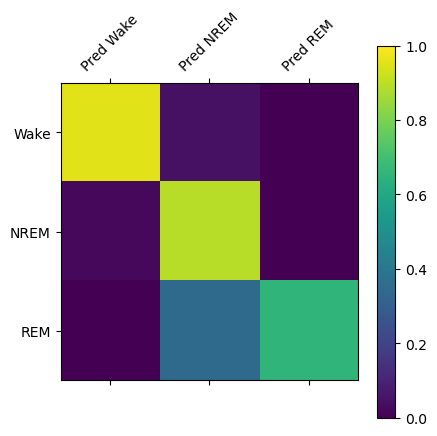

In [32]:
idx_1_0 = np.where(np.logical_and(state_prediction[:, 0] > 0, data_states.flatten() == 1))[0] # NREM predicted as wake
idx_1_1 = np.where(np.logical_and(state_prediction[:, 1] > 0, data_states.flatten() == 1))[0] # NREM predicted as NREM
idx_1_2 = np.where(np.logical_and(state_prediction[:, 2] > 0, data_states.flatten() == 1))[0] # NREM predicted as REM

idx_2_0 = np.where(np.logical_and(state_prediction[:, 0] > 0, data_states.flatten() == 2))[0] # REM predicted as wake
idx_2_1 = np.where(np.logical_and(state_prediction[:, 1] > 0, data_states.flatten() == 2))[0] # REM predicted as NREM
idx_2_2 = np.where(np.logical_and(state_prediction[:, 2] > 0, data_states.flatten() == 2))[0] # REM predicted as REM

idx_0_0 = np.where(np.logical_and(state_prediction[:, 0] > 0, data_states.flatten() == 0))[0] # wake predicted as wake
idx_0_1 = np.where(np.logical_and(state_prediction[:, 1] > 0, data_states.flatten() == 0))[0] # wake predicted as NREM
idx_0_2 = np.where(np.logical_and(state_prediction[:, 2] > 0, data_states.flatten() == 0))[0] # wake predicted as REM


confusionMatrix = [np.asarray([idx_0_0.size, idx_0_1.size, idx_0_2.size]) / (idx_0_0.size + idx_0_1.size + idx_0_2.size),
                   np.asarray([idx_1_0.size, idx_1_1.size, idx_1_2.size]) / (idx_1_0.size + idx_1_1.size + idx_2_2.size),
                   np.asarray([idx_2_0.size, idx_2_1.size, idx_2_2.size]) / (idx_2_0.size + idx_2_1.size + idx_2_2.size)]
plt.figure(dpi=200)
plt.matshow(confusionMatrix, vmin=0, vmax=1)
plt.colorbar()
plt.xticks([0, 1, 2], ['Pred Wake', 'Pred NREM', 'Pred REM'], rotation=45)
plt.yticks([0, 1, 2], ['Wake', 'NREM', 'REM'])

Plot the predicted states along with annotates one

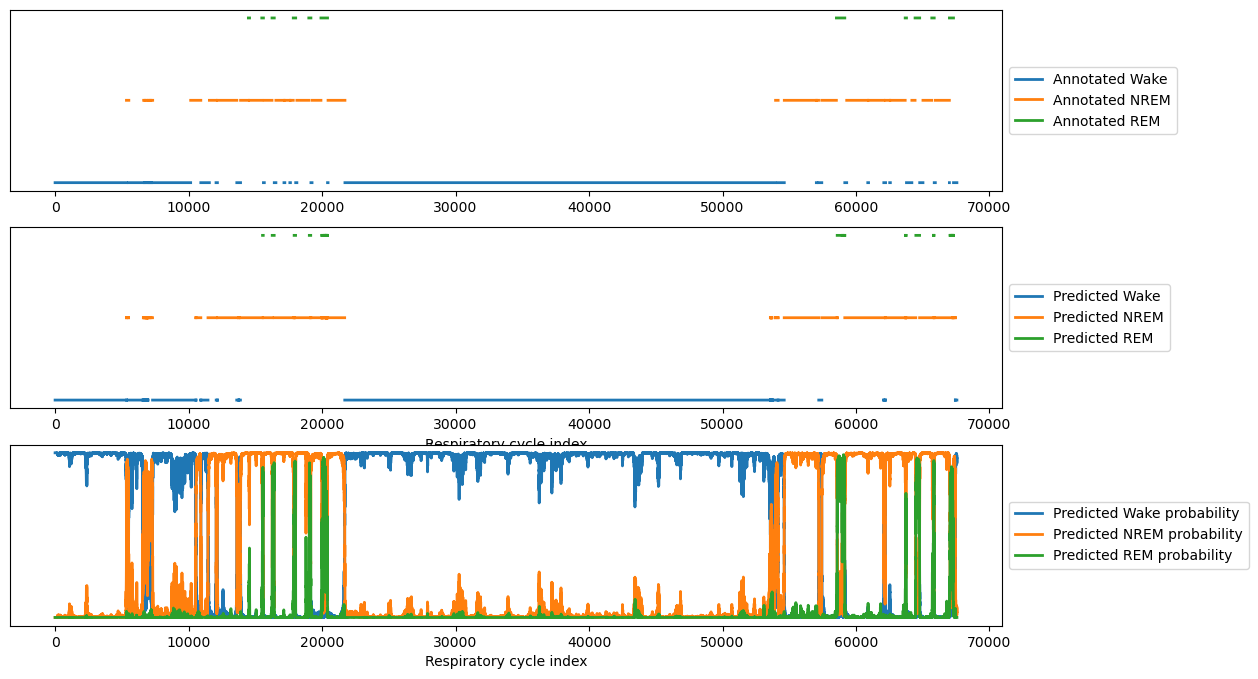

In [33]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize = (16, 8))

plt_legends = []
tmp = np.full(data_states.shape, np.nan)
tmp[data_states == 0] = 0
ax[0].plot(tmp, linewidth=2)
plt_legends.append('Annotated Wake')
tmp = np.full(data_states.shape, np.nan)
tmp[data_states == 1] = 1
ax[0].plot(tmp, linewidth=2)
plt_legends.append('Annotated NREM')
tmp = np.full(data_states.shape, np.nan)
tmp[data_states == 2] = 2
ax[0].plot(tmp, linewidth=2)
plt_legends.append('Annotated REM')
#plt.xlabel('Respiratory cycle index')
ax[0].set_yticks([])
box = ax[0].get_position()
ax[0].set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax[0].legend(plt_legends, loc='center left', bbox_to_anchor=(1, 0.5))


plt_legends = []
tmp = np.full(data_states.shape, np.nan)
tmp[state_prediction[:, 0]==1] = 0
ax[1].plot(tmp, linewidth=2)
plt_legends.append('Predicted Wake')

tmp = np.full(data_states.shape, np.nan)
tmp[state_prediction[:, 1]==1] = 1
ax[1].plot(tmp, linewidth=2)
plt_legends.append('Predicted NREM')

tmp = np.full(data_states.shape, np.nan)
tmp[state_prediction[:, 2]==1] = 2
ax[1].plot(tmp, linewidth=2)
plt_legends.append('Predicted REM')

ax[1].set_xlabel('Respiratory cycle index')


ax[1].set_yticks([])

box = ax[1].get_position()
ax[1].set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax[1].legend(plt_legends, loc='center left', bbox_to_anchor=(1, 0.5))


plt_legends = []

ax[2].plot(state_probability_prediction[:, 0], linewidth=2)
plt_legends.append('Predicted Wake probability')

ax[2].plot(state_probability_prediction[:, 1], linewidth=2)
plt_legends.append('Predicted NREM probability')

ax[2].plot(state_probability_prediction[:, 2], linewidth=2)
plt_legends.append('Predicted REM probability')

ax[2].set_xlabel('Respiratory cycle index')

ax[2].set_yticks([])

box = ax[2].get_position()
ax[2].set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax[2].legend(plt_legends, loc='center left', bbox_to_anchor=(1, 0.5))
